In [ ]:
# 1. Import libraries

# Standard utilities
import warnings
import pandas as pd
import numpy as np
import shap

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Data Splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Settings
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

In [ ]:
# Install lightgbm
!pip install lightgbm -q

In [ ]:
# Load data:
df = pd.read_csv("Churn_Modelling.csv")
print(f"Shape: {df.shape}")
print(df.head(3).to_string())
print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nTarget distribution:\n", df["Exited"].value_counts(normalize=True).round(3))

Shape: (10000, 14)
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  Exited
0          1    15634602  Hargrave          619    France  Female   42       2       0.00              1          1               1        101348.88       1
1          2    15647311      Hill          608     Spain  Female   41       1   83807.86              1          0               1        112542.58       0
2          3    15619304      Onio          502    France  Female   42       8  159660.80              3          1               0        113931.57       1

Missing values:
 Series([], dtype: int64)

Target distribution:
 Exited
0    0.796
1    0.204
Name: proportion, dtype: float64


# EDA

In [ ]:
# Load data
df = pd.read_csv("Churn_Modelling.csv")
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

print("EXPLORATORY DATA ANALYSIS")

EXPLORATORY DATA ANALYSIS


In [ ]:
# 1. OVERVIEW
print("\n1. Overview")
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())


1. Overview
Shape: (10000, 11)

Missing values:
 CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64



2. Target Distribution


/tmp/ipykernel_4379/4235662164.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Stayed", "Exited"])


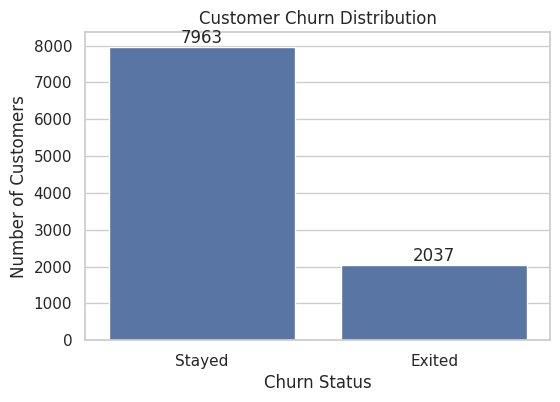

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


In [ ]:
# 2. TARGET DISTRIBUTION
print("\n2. Target Distribution")

plt.figure(figsize=(6,4))
ax = sns.countplot(x='Exited', data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

ax.set_xticklabels(["Stayed", "Exited"])

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom')

plt.show()

print(df['Exited'].value_counts(normalize=True))


3. Numerical Features vs Churn


/tmp/ipykernel_4379/1653684122.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Stayed", "Exited"])
/tmp/ipykernel_4379/1653684122.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Stayed", "Exited"])


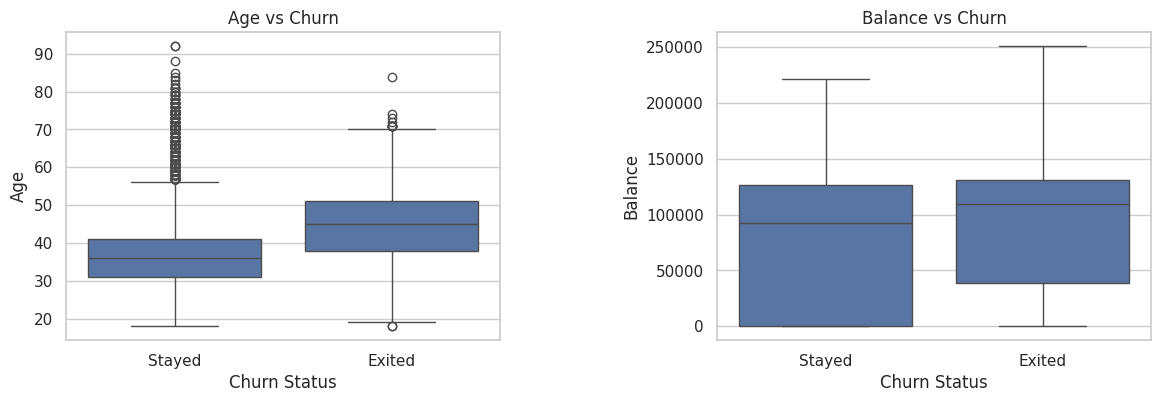

In [ ]:
# 3. NUMERICAL FEATURES VS CHURN
print("\n3. Numerical Features vs Churn")

num_cols = ['Age', 'Balance']

fig, axes = plt.subplots(1, 2, figsize=(14,4))

for i, col in enumerate(num_cols):
    sns.boxplot(x='Exited', y=col, data=df, ax=axes[i])

    axes[i].set_title(f"{col} vs Churn")
    axes[i].set_xlabel("Churn Status")
    axes[i].set_ylabel(col)
    axes[i].set_xticklabels(["Stayed", "Exited"])

plt.subplots_adjust(wspace=0.5)
plt.show()


4. Categorical Features vs Churn


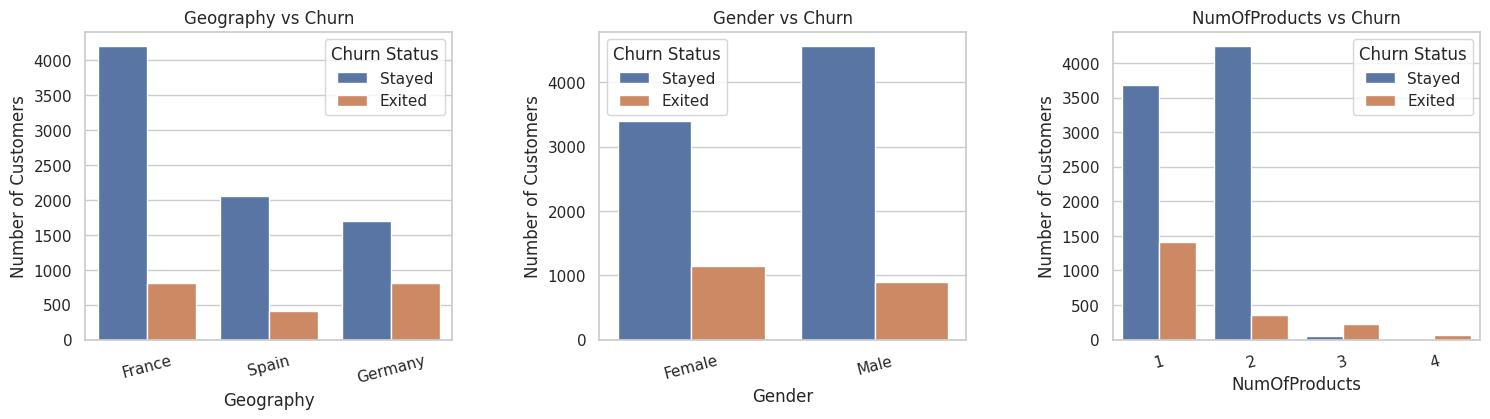

In [ ]:
# 4. CATEGORICAL FEATURES VS CHURN
print("\n4. Categorical Features vs Churn")

cat_cols = ['Geography', 'Gender', 'NumOfProducts']

fig, axes = plt.subplots(1, 3, figsize=(18,4))

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='Exited', data=df, ax=axes[i])

    axes[i].set_title(f"{col} vs Churn")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Number of Customers")

    handles, _ = axes[i].get_legend_handles_labels()
    axes[i].legend(handles, ["Stayed", "Exited"], title="Churn Status")

    axes[i].tick_params(axis='x', rotation=15)

plt.subplots_adjust(wspace=0.4)
plt.show()

In [ ]:
# 5. CHURN RATE ANALYSIS
print("\n5. Churn Rate Analysis")

def churn_rate(col):
    return df.groupby(col)['Exited'].mean().sort_values(ascending=False)

for col in ['Geography', 'NumOfProducts']:
    print(f"\nChurn rate by {col}:")
    print(churn_rate(col))


5. Churn Rate Analysis

Churn rate by Geography:
Geography
Germany    0.324432
Spain      0.166734
France     0.161548
Name: Exited, dtype: float64

Churn rate by NumOfProducts:
NumOfProducts
4    1.000000
3    0.827068
1    0.277144
2    0.075817
Name: Exited, dtype: float64



6. Correlation Matrix


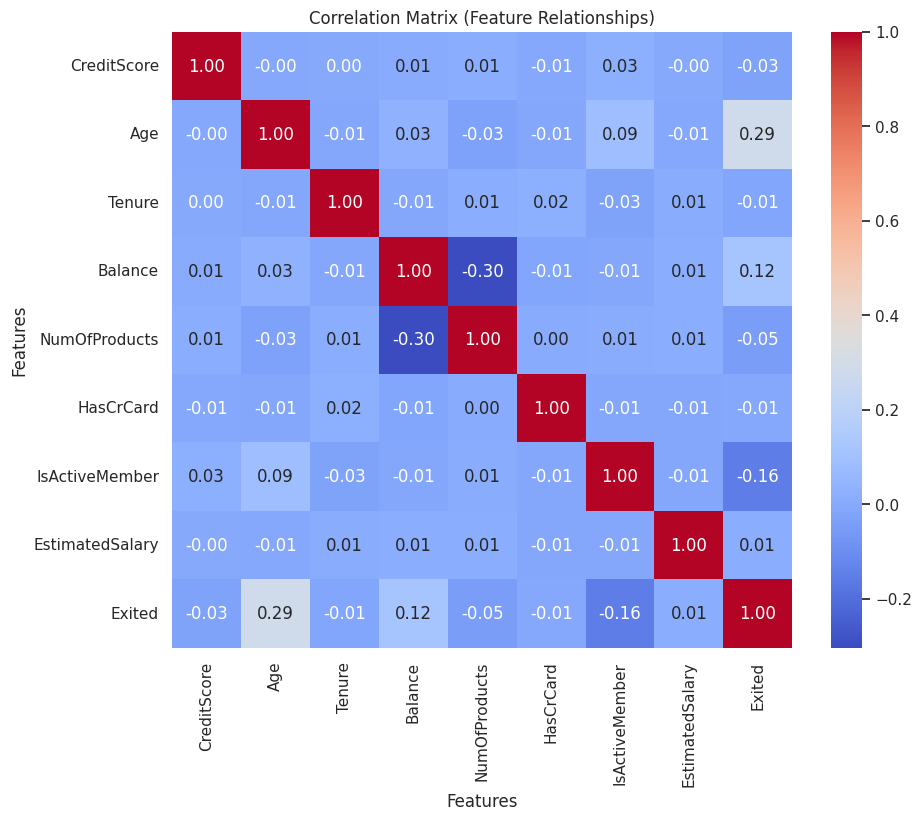


EDA COMPLETED


In [ ]:
# 6. CORRELATION MATRIX
print("\n6. Correlation Matrix")

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Matrix (Feature Relationships)")
plt.xlabel("Features")
plt.ylabel("Features")

plt.show()

print("\nEDA COMPLETED")

# 5. Data Processing

In [ ]:

# 5.1. CATEGORICAL ENCODING
df_encoded = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

# 5.2. TRAIN - DEV - TEST SPLIT
X = df_encoded.drop('Exited', axis=1)
y = df_encoded['Exited']

#Step 1: Separate the Test Set (20%)
X_train_dev, X_test, y_train_dev, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#Step 2: Separate the Training (70%) and Dev (10%) sets from the rest.
X_train, X_dev, y_train, y_dev = train_test_split(
    X_train_dev, y_train_dev, test_size=0.125, random_state=42, stratify=y_train_dev
)

print(f"Dimensions of the data sets:")
print(f"- Train: {X_train.shape[0]} template")
print(f"- Dev: {X_dev.shape[0]} template")
print(f"- Test: {X_test.shape[0]} template")

# 5.3. FEATURE SCALING (Standardization)
cols_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
scaler = StandardScaler()
scaler.fit(X_train[cols_to_scale])

X_train_scaled = X_train.copy()
X_dev_scaled = X_dev.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.transform(X_train[cols_to_scale])
X_dev_scaled[cols_to_scale] = scaler.transform(X_dev[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# 5.4. HANDLING CLASS IMBALANCE (SMOTE)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("\nPreprocessing complete!")
print(f"Churn class ratio in Train set after SMOTE: {y_train_resampled.value_counts(normalize=True).to_dict()}")


Dimensions of the data sets:
- Train: 7000 template
- Dev: 1000 template
- Test: 2000 template

Preprocessing complete!
Churn class ratio in Train set after SMOTE: {1: 0.5, 0: 0.5}


Multi-Layer Perceptron (MLP)

BUILD MODEL

In [ ]:
model = MLPClassifier(
    hidden_layer_sizes=(128,64,32,16),
    activation='relu',
    alpha=0.01,
    learning_rate_init=0.001,
    max_iter=1500,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=42
)

TRAIN MODEL

In [ ]:
model.fit(X_train_resampled, y_train_resampled)

MLPClassifier(alpha=0.01, early_stopping=True,
              hidden_layer_sizes=(128, 64, 32, 16), max_iter=1500,
              n_iter_no_change=20, random_state=42, validation_fraction=0.15)

PREDICTION

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

EVALUATION

In [ ]:
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.85      0.37      0.52      1593
           1       0.23      0.75      0.36       407

    accuracy                           0.45      2000
   macro avg       0.54      0.56      0.44      2000
weighted avg       0.73      0.45      0.49      2000

ROC-AUC: 0.5608767473174254


*CONFUSION* MATRIX (VISUALIZATION)

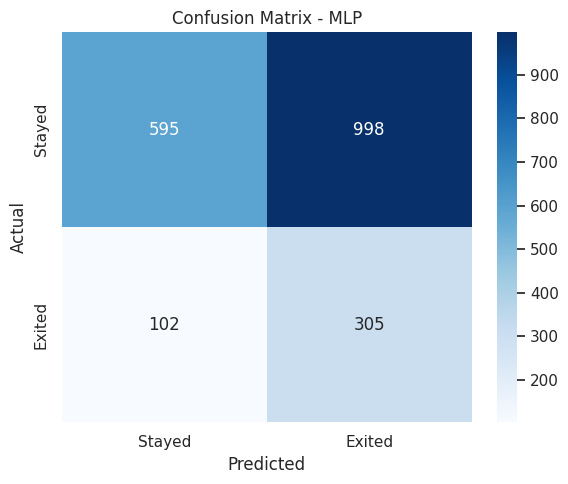

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed','Exited'],
            yticklabels=['Stayed','Exited'])

plt.title("Confusion Matrix - MLP")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

**ROC** CURVE

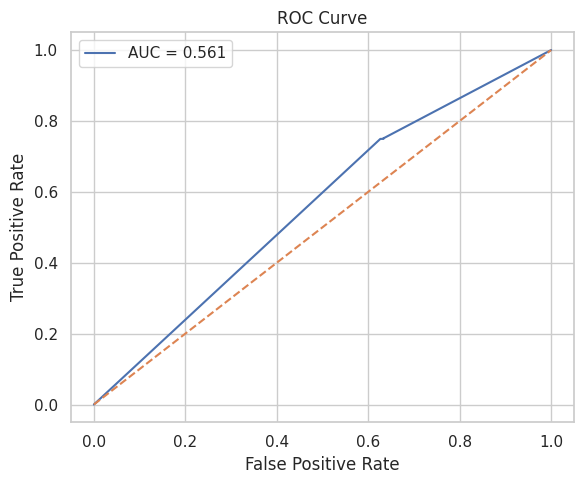

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc(fpr,tpr):.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

# Random forest

In [ ]:
# 1. Initialize the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# 2. Train the model using the variables from the MLP pipeline
rf_model.fit(X_train_resampled, y_train_resampled)

# 3. Make predictions on the preprocessed test set
y_pred_dev = rf_model.predict(X_dev_scaled)
y_prob_dev = rf_model.predict_proba(X_dev_scaled)[:, 1]

# 4. Output evaluation metrics
print("--- EVALUATION ON DEV SET ---")
print("\nClassification Report:\n", classification_report(y_dev, y_pred_dev))
print("\nConfusion Matrix:\n", confusion_matrix(y_dev, y_pred_dev))
print(f"\nROC-AUC Score(dev): {roc_auc_score(y_dev, y_prob_dev):.4f}")

y_pred_test = rf_model.predict(X_test_scaled)
y_prob_test = rf_model.predict_proba(X_test_scaled)[:, 1]
print("--- FINAL EVALUATION ON TEST SET ---")
print(classification_report(y_test, y_pred_test))
test_auc = roc_auc_score(y_test, y_prob_test)
print(f"ROC-AUC Score (Test): {test_auc:.4f}")

--- EVALUATION ON DEV SET ---

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.88      0.90       796
           1       0.61      0.69      0.65       204

    accuracy                           0.84      1000
   macro avg       0.76      0.79      0.77      1000
weighted avg       0.85      0.84      0.85      1000


Confusion Matrix:
 [[704  92]
 [ 63 141]]

ROC-AUC Score(dev): 0.8708
--- FINAL EVALUATION ON TEST SET ---
              precision    recall  f1-score   support

           0       0.91      0.86      0.89      1593
           1       0.56      0.67      0.61       407

    accuracy                           0.82      2000
   macro avg       0.73      0.76      0.75      2000
weighted avg       0.84      0.82      0.83      2000

ROC-AUC Score (Test): 0.8586


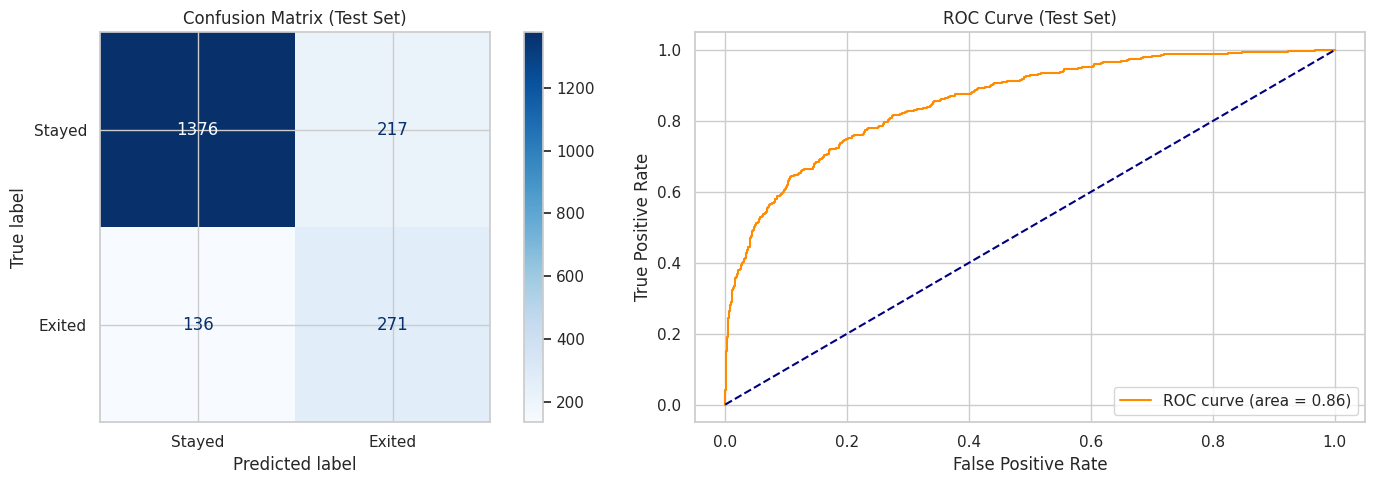

In [ ]:
#1. Draw the Confusion Matrix
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ConfusionMatrixDisplay.from_estimator(rf_model, X_test_scaled, y_test,
                                      display_labels=['Stayed', 'Exited'],
                                      cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix (Test Set)')

# 2. Draw the ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, rf_model.predict_proba(X_test_scaled)[:, 1])
roc_auc = auc(fpr, tpr)
ax[1].plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('ROC Curve (Test Set)')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# Gradient Boosting

In [ ]:
# Initialize Model
print("TRAINING GRADIENT BOOSTING MODEL")

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

TRAINING GRADIENT BOOSTING MODEL


In [ ]:
# TRAIN MODEL (Train set)
gb_model.fit(X_train_resampled, y_train_resampled)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

In [ ]:
# EVALUATE ON DEV SET
y_dev_pred = gb_model.predict(X_dev_scaled)
y_dev_proba = gb_model.predict_proba(X_dev_scaled)[:, 1]

print("\nDEV SET EVALUATION")

print("Accuracy:", accuracy_score(y_dev, y_dev_pred))
print("ROC-AUC:", roc_auc_score(y_dev, y_dev_proba))

print("\nClassification Report:\n", classification_report(y_dev, y_dev_pred))


DEV SET EVALUATION
Accuracy: 0.858
ROC-AUC: 0.8633270519262982

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91       796
           1       0.65      0.67      0.66       204

    accuracy                           0.86      1000
   macro avg       0.78      0.79      0.78      1000
weighted avg       0.86      0.86      0.86      1000



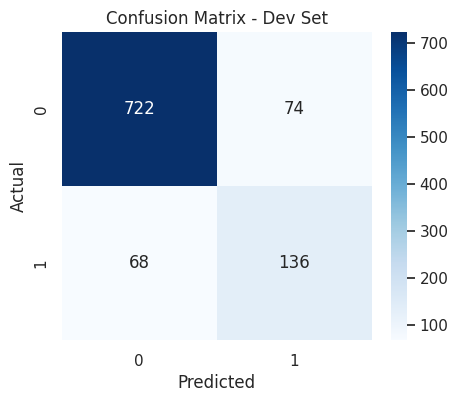

In [ ]:
# Confusion Matrix (Dev)
cm_dev = confusion_matrix(y_dev, y_dev_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_dev, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Dev Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# TUNE THRESHOLD ON DEV
threshold = 0.4

y_dev_pred_custom = (y_dev_proba >= threshold).astype(int)

print("\nDEV SET WITH CUSTOM THRESHOLD =", threshold)
print(classification_report(y_dev, y_dev_pred_custom))


DEV SET WITH CUSTOM THRESHOLD = 0.4
              precision    recall  f1-score   support

           0       0.92      0.83      0.87       796
           1       0.53      0.74      0.61       204

    accuracy                           0.81      1000
   macro avg       0.73      0.78      0.74      1000
weighted avg       0.84      0.81      0.82      1000



In [ ]:
# FINAL EVALUATION ON TEST SET
y_test_proba = gb_model.predict_proba(X_test_scaled)[:, 1]

threshold = 0.4
y_test_pred = (y_test_proba >= threshold).astype(int)

print("\nTEST SET FINAL EVALUATION")

print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_test_proba))

print("\nClassification Report:\n", classification_report(y_test, y_test_pred))


TEST SET FINAL EVALUATION
Accuracy: 0.7905
ROC-AUC: 0.862930727337507

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.80      0.86      1593
           1       0.49      0.76      0.60       407

    accuracy                           0.79      2000
   macro avg       0.71      0.78      0.73      2000
weighted avg       0.84      0.79      0.81      2000



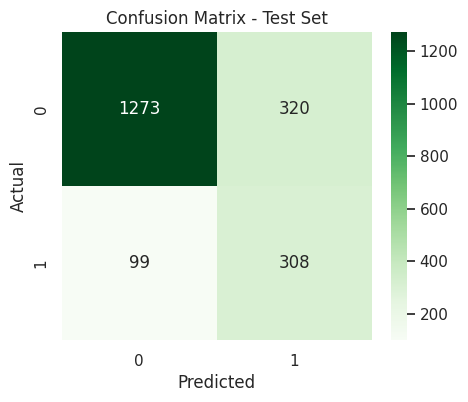

In [ ]:
# Confusion Matrix (Test)
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens')

plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#Logistic Regression


In [ ]:
# 2. Load dataset
df = pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# 13. Drop unnecessary columns

columns_to_drop = [
    "RowNumber",
    "CustomerId",
    "Surname"
]

df_model = df.drop(columns=columns_to_drop)

df_model.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# 14. Define features and target

X = df_model.drop(columns=["Exited"])
y = df_model["Exited"]

print("Feature matrix shape:")
print(X.shape)
print("\nTarget vector shape:")
print(y.shape)
print("\nFeatures:")
print(X.columns.tolist())
print("\nTarget:")
print(y.name)

Feature matrix shape:
(10000, 10)

Target vector shape:
(10000,)

Features:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

Target:
Exited


In [ ]:
# 15. Split data into training and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True) * 100)

X_train shape: (8000, 10)
X_test shape: (2000, 10)
y_train shape: (8000,)
y_test shape: (2000,)

Train target distribution:
Exited
0    79.625
1    20.375
Name: proportion, dtype: float64

Test target distribution:
Exited
0    79.65
1    20.35
Name: proportion, dtype: float64


In [ ]:
# 16. Identify categorical and numerical features

categorical_features = [
    "Geography",
    "Gender"
]

numerical_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary"
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Geography', 'Gender']

Numerical features:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


In [ ]:
# 17. Create preprocessing pipeline for Logistic Regression

# Create OneHotEncoder
# handle_unknown="ignore" prevents errors if test data contains unseen categories
encoder = OneHotEncoder(handle_unknown="ignore")

# Create preprocessing pipeline for Logistic Regression
logistic_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", encoder, categorical_features)
    ]
)

In [ ]:
# 18. Train Logistic Regression baseline model
# Create Logistic Regression pipeline
logistic_model = Pipeline(
    steps=[
        ("preprocessor", logistic_preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

# Train the model using training data
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Geography', 'Gender'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

Logistic Regression Baseline Results
Accuracy:  0.7135
Precision: 0.3872
Recall:    0.7002
F1-score:  0.4987
ROC-AUC:   0.7772

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000



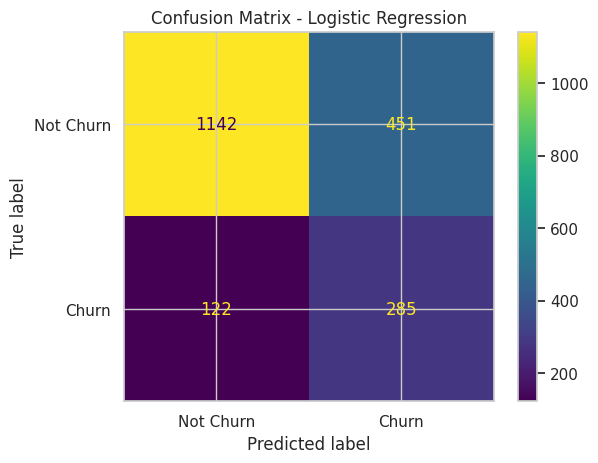

In [ ]:
# 19. Evaluate Logistic Regression baseline model

# Predict class labels on the test set
y_pred_logistic = logistic_model.predict(X_test)

# Predict churn probabilities on the test set
y_proba_logistic = logistic_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)
roc_auc_logistic = roc_auc_score(y_test, y_proba_logistic)

print("Logistic Regression Baseline Results")
print("=" * 45)
print(f"Accuracy:  {accuracy_logistic:.4f}")
print(f"Precision: {precision_logistic:.4f}")
print(f"Recall:    {recall_logistic:.4f}")
print(f"F1-score:  {f1_logistic:.4f}")
print(f"ROC-AUC:   {roc_auc_logistic:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

# Confusion matrix
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Not Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# Light Grandiant Boosting Machine (LightGBM)

In [ ]:
# 20. Create preprocessing pipeline for LightGBM
# Create OneHotEncoder for categorical variables
lgbm_encoder = OneHotEncoder(handle_unknown="ignore")

# Create preprocessing pipeline for LightGBM
lgbm_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", lgbm_encoder, categorical_features)
    ]
)

In [ ]:
# 21. Train LightGBM model

from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier

lgbm_model = Pipeline(
    steps=[
        ("preprocessor", lgbm_preprocessor),
        ("model", LGBMClassifier(
            objective="binary",
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        ))
    ]
)

lgbm_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Geography', 'Gender'])])),
                ('model',
                 LGBMClassifier(class_weight='balanced', n_jobs=-1,
                                objective='binary', random_state=42,
                                verbosity=-1))])

LightGBM Model Results
Accuracy:  0.8130
Precision: 0.5303
Recall:    0.7101
F1-score:  0.6071
ROC-AUC:   0.8573

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.84      0.88      1593
           1       0.53      0.71      0.61       407

    accuracy                           0.81      2000
   macro avg       0.72      0.77      0.74      2000
weighted avg       0.84      0.81      0.82      2000



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


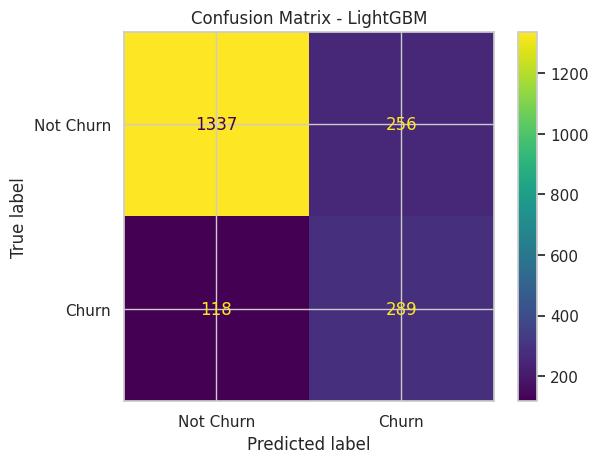

In [ ]:
# 22. Evaluate LightGBM model

# Predict class labels on the test set
y_pred_lgbm = lgbm_model.predict(X_test)

# Predict churn probabilities on the test set
y_proba_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy_lgbm = accuracy_score(y_test, y_pred_lgbm)
precision_lgbm = precision_score(y_test, y_pred_lgbm)
recall_lgbm = recall_score(y_test, y_pred_lgbm)
f1_lgbm = f1_score(y_test, y_pred_lgbm)
roc_auc_lgbm = roc_auc_score(y_test, y_proba_lgbm)

print("LightGBM Model Results")
print("=" * 45)
print(f"Accuracy:  {accuracy_lgbm:.4f}")
print(f"Precision: {precision_lgbm:.4f}")
print(f"Recall:    {recall_lgbm:.4f}")
print(f"F1-score:  {f1_lgbm:.4f}")
print(f"ROC-AUC:   {roc_auc_lgbm:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm))

# Confusion matrix
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lgbm,
    display_labels=["Not Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - LightGBM")
plt.show()

In [ ]:
# 23. Compare Logistic Regression and LightGBM results

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "LightGBM"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_lgbm
    ],
    "Precision": [
        precision_logistic,
        precision_lgbm
    ],
    "Recall": [
        recall_logistic,
        recall_lgbm
    ],
    "F1-score": [
        f1_logistic,
        f1_lgbm
    ],
    "ROC-AUC": [
        roc_auc_logistic,
        roc_auc_lgbm
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.7135,0.387228,0.700246,0.498688,0.777165
1,LightGBM,0.8130,0.530275,0.710074,0.607143,0.857316


In [ ]:
# 24. Tune LightGBM hyperparameters using RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV

# Create a new LightGBM pipeline for tuning
lgbm_tuning_model = Pipeline(
    steps=[
        ("preprocessor", lgbm_preprocessor),
        ("model", LGBMClassifier(
            objective="binary",
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        ))
    ]
)

# Define hyperparameter search space
param_distributions = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.07, 0.1],
    "model__num_leaves": [15, 31, 45, 63],
    "model__max_depth": [3, 5, 7, -1],
    "model__min_child_samples": [10, 20, 30, 50, 70],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__reg_alpha": [0, 0.01, 0.1, 0.5, 1],
    "model__reg_lambda": [0, 0.01, 0.1, 0.5, 1]
}

# Set up RandomizedSearchCV
random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm_tuning_model,
    param_distributions=param_distributions,
    n_iter=40,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Train and tune only on the training set
random_search_lgbm.fit(X_train, y_train)

print("Best ROC-AUC score from cross-validation:")
print(random_search_lgbm.best_score_)

print("\nBest hyperparameters:")
print(random_search_lgbm.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best ROC-AUC score from cross-validation:
0.8666925099440437

Best hyperparameters:
{'model__subsample': 0.9, 'model__reg_lambda': 1, 'model__reg_alpha': 0.01, 'model__num_leaves': 45, 'model__n_estimators': 300, 'model__min_child_samples': 50, 'model__max_depth': 5, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.9}


Tuned LightGBM Model Results
Accuracy:  0.8000
Precision: 0.5058
Recall:    0.7445
F1-score:  0.6024
ROC-AUC:   0.8670

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.81      0.87      1593
           1       0.51      0.74      0.60       407

    accuracy                           0.80      2000
   macro avg       0.72      0.78      0.73      2000
weighted avg       0.84      0.80      0.81      2000



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


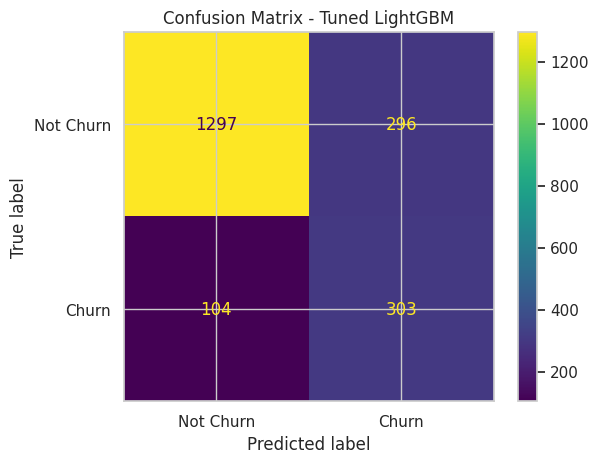

In [ ]:
# 25. Evaluate tuned LightGBM model

# Get the best LightGBM pipeline from RandomizedSearchCV
best_lgbm_model = random_search_lgbm.best_estimator_

# Predict class labels on the test set
y_pred_lgbm_tuned = best_lgbm_model.predict(X_test)

# Predict churn probabilities on the test set
y_proba_lgbm_tuned = best_lgbm_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy_lgbm_tuned = accuracy_score(y_test, y_pred_lgbm_tuned)
precision_lgbm_tuned = precision_score(y_test, y_pred_lgbm_tuned)
recall_lgbm_tuned = recall_score(y_test, y_pred_lgbm_tuned)
f1_lgbm_tuned = f1_score(y_test, y_pred_lgbm_tuned)
roc_auc_lgbm_tuned = roc_auc_score(y_test, y_proba_lgbm_tuned)

print("Tuned LightGBM Model Results")
print("=" * 45)
print(f"Accuracy:  {accuracy_lgbm_tuned:.4f}")
print(f"Precision: {precision_lgbm_tuned:.4f}")
print(f"Recall:    {recall_lgbm_tuned:.4f}")
print(f"F1-score:  {f1_lgbm_tuned:.4f}")
print(f"ROC-AUC:   {roc_auc_lgbm_tuned:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm_tuned))

# Confusion matrix
cm_lgbm_tuned = confusion_matrix(y_test, y_pred_lgbm_tuned)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lgbm_tuned,
    display_labels=["Not Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Tuned LightGBM")
plt.show()

In [ ]:
# 26. Compare all model results

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "LightGBM Default",
        "LightGBM Tuned"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_lgbm,
        accuracy_lgbm_tuned
    ],
    "Precision": [
        precision_logistic,
        precision_lgbm,
        precision_lgbm_tuned
    ],
    "Recall": [
        recall_logistic,
        recall_lgbm,
        recall_lgbm_tuned
    ],
    "F1-score": [
        f1_logistic,
        f1_lgbm,
        f1_lgbm_tuned
    ],
    "ROC-AUC": [
        roc_auc_logistic,
        roc_auc_lgbm,
        roc_auc_lgbm_tuned
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.7135,0.387228,0.700246,0.498688,0.777165
1,LightGBM Default,0.8130,0.530275,0.710074,0.607143,0.857316
2,LightGBM Tuned,0.8000,0.505843,0.744472,0.602386,0.866955


In [ ]:
# 27. Find the best threshold for Tuned LightGBM using a validation set

from sklearn.base import clone

# Split the original training set into a smaller training set and a validation set
X_train_inner, X_val, y_train_inner, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Clone the tuned LightGBM model so we can retrain it only on X_train_inner
lgbm_threshold_model = clone(best_lgbm_model)

# Train the cloned tuned model on the inner training set
lgbm_threshold_model.fit(X_train_inner, y_train_inner)

# Predict churn probabilities on the validation set
y_val_proba = lgbm_threshold_model.predict_proba(X_val)[:, 1]

# Try different threshold values
thresholds = np.arange(0.10, 0.91, 0.01)

threshold_results = []

for threshold in thresholds:
    y_val_pred = (y_val_proba >= threshold).astype(int)

    accuracy = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred, zero_division=0)
    recall = recall_score(y_val, y_val_pred, zero_division=0)
    f1 = f1_score(y_val, y_val_pred, zero_division=0)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

threshold_results_df = pd.DataFrame(threshold_results)

# Sort thresholds by F1-score
threshold_results_df = threshold_results_df.sort_values(
    by="F1-score",
    ascending=False
)

threshold_results_df.head(10)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Threshold,Accuracy,Precision,Recall,F1-score
50,0.60,0.843125,0.607450,0.650307,0.628148
52,0.62,0.846250,0.620482,0.631902,0.626140
49,0.59,0.839375,0.596100,0.656442,0.624818
51,0.61,0.843125,0.609329,0.641104,0.624813
48,0.58,0.837500,0.590164,0.662577,0.624277
47,0.57,0.835000,0.582447,0.671779,0.623932
65,0.75,0.869375,0.755459,0.530675,0.623423
55,0.65,0.851250,0.643791,0.604294,0.623418
54,0.64,0.849375,0.635783,0.610429,0.622848
58,0.68,0.856875,0.672598,0.579755,0.622735


Selected threshold:
0.5999999999999998
Tuned LightGBM with Optimized Threshold Results
Threshold:  0.60
Accuracy:   0.8370
Precision:  0.5867
Recall:     0.6732
F1-score:   0.6270
ROC-AUC:    0.8670

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.90      1593
           1       0.59      0.67      0.63       407

    accuracy                           0.84      2000
   macro avg       0.75      0.78      0.76      2000
weighted avg       0.85      0.84      0.84      2000



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


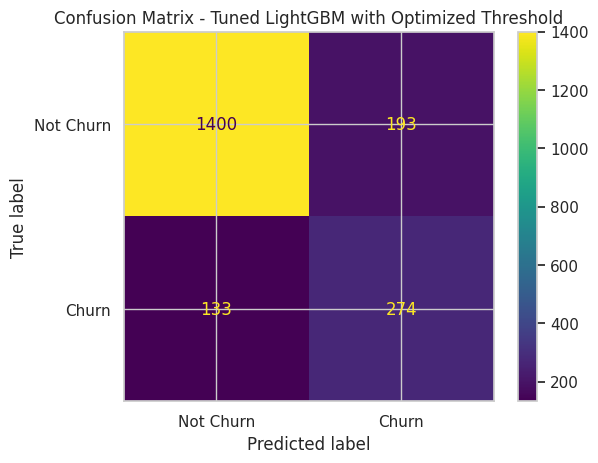

In [ ]:
# 28. Evaluate Tuned LightGBM using the selected threshold

# Select the best threshold based on validation F1-score
best_threshold = threshold_results_df.iloc[0]["Threshold"]

print("Selected threshold:")
print(best_threshold)

# Predict churn probabilities on the test set using the tuned LightGBM model
y_proba_lgbm_tuned_threshold = best_lgbm_model.predict_proba(X_test)[:, 1]

# Convert probabilities into class labels using the selected threshold
y_pred_lgbm_tuned_threshold = (y_proba_lgbm_tuned_threshold >= best_threshold).astype(int)

# Calculate evaluation metrics
accuracy_lgbm_tuned_threshold = accuracy_score(y_test, y_pred_lgbm_tuned_threshold)
precision_lgbm_tuned_threshold = precision_score(y_test, y_pred_lgbm_tuned_threshold)
recall_lgbm_tuned_threshold = recall_score(y_test, y_pred_lgbm_tuned_threshold)
f1_lgbm_tuned_threshold = f1_score(y_test, y_pred_lgbm_tuned_threshold)
roc_auc_lgbm_tuned_threshold = roc_auc_score(y_test, y_proba_lgbm_tuned_threshold)

print("Tuned LightGBM with Optimized Threshold Results")
print("=" * 55)
print(f"Threshold:  {best_threshold:.2f}")
print(f"Accuracy:   {accuracy_lgbm_tuned_threshold:.4f}")
print(f"Precision:  {precision_lgbm_tuned_threshold:.4f}")
print(f"Recall:     {recall_lgbm_tuned_threshold:.4f}")
print(f"F1-score:   {f1_lgbm_tuned_threshold:.4f}")
print(f"ROC-AUC:    {roc_auc_lgbm_tuned_threshold:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm_tuned_threshold))

# Confusion matrix
cm_lgbm_tuned_threshold = confusion_matrix(y_test, y_pred_lgbm_tuned_threshold)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lgbm_tuned_threshold,
    display_labels=["Not Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Tuned LightGBM with Optimized Threshold")
plt.show()

In [ ]:
# 29. Comparison of all models

final_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "LightGBM Default",
        "LightGBM Tuned",
        "LightGBM Tuned + Threshold 0.60"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_lgbm,
        accuracy_lgbm_tuned,
        accuracy_lgbm_tuned_threshold
    ],
    "Precision": [
        precision_logistic,
        precision_lgbm,
        precision_lgbm_tuned,
        precision_lgbm_tuned_threshold
    ],
    "Recall": [
        recall_logistic,
        recall_lgbm,
        recall_lgbm_tuned,
        recall_lgbm_tuned_threshold
    ],
    "F1-score": [
        f1_logistic,
        f1_lgbm,
        f1_lgbm_tuned,
        f1_lgbm_tuned_threshold
    ],
    "ROC-AUC": [
        roc_auc_logistic,
        roc_auc_lgbm,
        roc_auc_lgbm_tuned,
        roc_auc_lgbm_tuned_threshold
    ]
})

final_model_comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.7135,0.387228,0.700246,0.498688,0.777165
1,LightGBM Default,0.8130,0.530275,0.710074,0.607143,0.857316
2,LightGBM Tuned,0.8000,0.505843,0.744472,0.602386,0.866955
3,LightGBM Tuned + Threshold 0.60,0.8370,0.586724,0.673219,0.627002,0.866955


**Fine-tunning**


In [ ]:
# 35. Fine-tune LightGBM with early stopping

from sklearn.base import clone
from lightgbm import early_stopping, log_evaluation

# Split the training set into inner training and validation sets
X_train_ft, X_val_ft, y_train_ft, y_val_ft = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Clone the LightGBM preprocessor
preprocessor_ft = clone(lgbm_preprocessor)

# Fit the preprocessor only on the inner training set
X_train_ft_transformed = preprocessor_ft.fit_transform(X_train_ft)

# Transform the validation set using the fitted preprocessor
X_val_ft_transformed = preprocessor_ft.transform(X_val_ft)

# Extract the best parameters from previous RandomizedSearchCV
best_params_clean = {
    key.replace("model__", ""): value
    for key, value in random_search_lgbm.best_params_.items()
}

# Use a high number of trees and let early stopping decide the best number
best_params_clean["n_estimators"] = 2000

# Create the fine-tuned LightGBM model
lgbm_finetuned_model = LGBMClassifier(
    objective="binary",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    **best_params_clean
)

# Train with early stopping
lgbm_finetuned_model.fit(
    X_train_ft_transformed,
    y_train_ft,
    eval_set=[(X_val_ft_transformed, y_val_ft)],
    eval_metric="auc",
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(period=100)
    ]
)

print("Best iteration found by early stopping:")
print(lgbm_finetuned_model.best_iteration_)

Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.865191	valid_0's binary_logloss: 0.450932
[200]	valid_0's auc: 0.869658	valid_0's binary_logloss: 0.429629
Early stopping, best iteration is:
[182]	valid_0's auc: 0.86989	valid_0's binary_logloss: 0.431375
Best iteration found by early stopping:
182


In [ ]:
# 36. Retrain fine-tuned LightGBM on the full training set

# Get the best number of trees found by early stopping
best_n_estimators = lgbm_finetuned_model.best_iteration_

print("Best number of estimators from early stopping:")
print(best_n_estimators)

# Create a new preprocessor for the final fine-tuned model
final_preprocessor_ft = clone(lgbm_preprocessor)

# Fit the preprocessor on the full training set
X_train_transformed_ft = final_preprocessor_ft.fit_transform(X_train)

# Transform the test set using the fitted preprocessor
X_test_transformed_ft = final_preprocessor_ft.transform(X_test)

# Prepare final fine-tuned parameters
final_ft_params = best_params_clean.copy()
final_ft_params["n_estimators"] = best_n_estimators

# Create the final fine-tuned LightGBM model
final_lgbm_finetuned_model = LGBMClassifier(
    objective="binary",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    **final_ft_params
)

# Train the final fine-tuned model on the full training set
final_lgbm_finetuned_model.fit(
    X_train_transformed_ft,
    y_train
)

Best number of estimators from early stopping:
182


LGBMClassifier(class_weight='balanced', colsample_bytree=0.9,
               learning_rate=0.03, max_depth=5, min_child_samples=50,
               n_estimators=182, n_jobs=-1, num_leaves=45, objective='binary',
               random_state=42, reg_alpha=0.01, reg_lambda=1, subsample=0.9,
               verbosity=-1)

Final Fine-Tuned LightGBM Results
Accuracy:  0.8010
Precision: 0.5074
Recall:    0.7617
F1-score:  0.6090
ROC-AUC:   0.8675

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.81      0.87      1593
           1       0.51      0.76      0.61       407

    accuracy                           0.80      2000
   macro avg       0.72      0.79      0.74      2000
weighted avg       0.84      0.80      0.81      2000



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


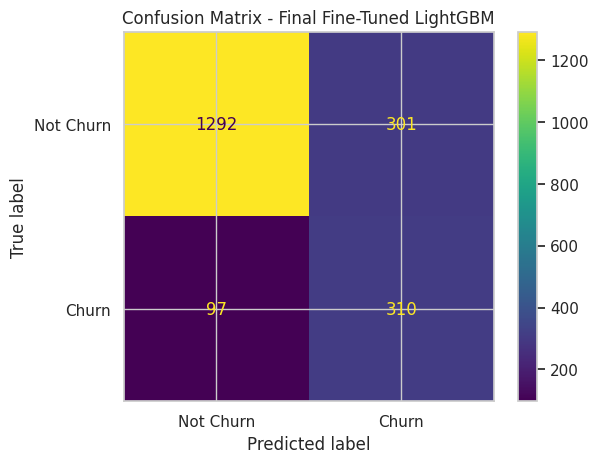

In [ ]:
# 37. Evaluate final fine-tuned LightGBM model

# Predict class labels on the transformed test set
y_pred_lgbm_finetuned = final_lgbm_finetuned_model.predict(X_test_transformed_ft)

# Predict churn probabilities on the transformed test set
y_proba_lgbm_finetuned = final_lgbm_finetuned_model.predict_proba(X_test_transformed_ft)[:, 1]

# Calculate evaluation metrics
accuracy_lgbm_finetuned = accuracy_score(y_test, y_pred_lgbm_finetuned)
precision_lgbm_finetuned = precision_score(y_test, y_pred_lgbm_finetuned, zero_division=0)
recall_lgbm_finetuned = recall_score(y_test, y_pred_lgbm_finetuned, zero_division=0)
f1_lgbm_finetuned = f1_score(y_test, y_pred_lgbm_finetuned, zero_division=0)
roc_auc_lgbm_finetuned = roc_auc_score(y_test, y_proba_lgbm_finetuned)

print("Final Fine-Tuned LightGBM Results")
print(f"Accuracy:  {accuracy_lgbm_finetuned:.4f}")
print(f"Precision: {precision_lgbm_finetuned:.4f}")
print(f"Recall:    {recall_lgbm_finetuned:.4f}")
print(f"F1-score:  {f1_lgbm_finetuned:.4f}")
print(f"ROC-AUC:   {roc_auc_lgbm_finetuned:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm_finetuned, zero_division=0))

# Confusion matrix
cm_lgbm_finetuned = confusion_matrix(y_test, y_pred_lgbm_finetuned)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lgbm_finetuned,
    display_labels=["Not Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Final Fine-Tuned LightGBM")
plt.show()

In [ ]:
# 38. Optimize threshold for fine-tuned LightGBM

# Use the validation model from Cell 37 to choose threshold
# This avoids choosing threshold directly from the test set

y_val_proba_finetuned = lgbm_finetuned_model.predict_proba(X_val_ft_transformed)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)

finetuned_threshold_results = []

for threshold in thresholds:
    y_val_pred_finetuned = (y_val_proba_finetuned >= threshold).astype(int)

    accuracy = accuracy_score(y_val_ft, y_val_pred_finetuned)
    precision = precision_score(y_val_ft, y_val_pred_finetuned, zero_division=0)
    recall = recall_score(y_val_ft, y_val_pred_finetuned, zero_division=0)
    f1 = f1_score(y_val_ft, y_val_pred_finetuned, zero_division=0)

    finetuned_threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

finetuned_threshold_df = pd.DataFrame(finetuned_threshold_results)

finetuned_threshold_df = finetuned_threshold_df.sort_values(
    by="F1-score",
    ascending=False
)

finetuned_threshold_df.head(10)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Threshold,Accuracy,Precision,Recall,F1-score
50,0.60,0.845625,0.613833,0.653374,0.632987
49,0.59,0.841875,0.601671,0.662577,0.630657
47,0.57,0.836250,0.584656,0.677914,0.627841
46,0.56,0.833125,0.576227,0.684049,0.625526
48,0.58,0.837500,0.589674,0.665644,0.625360
54,0.64,0.852500,0.649007,0.601227,0.624204
51,0.61,0.845625,0.619335,0.628834,0.624049
53,0.63,0.848750,0.633758,0.610429,0.621875
52,0.62,0.847500,0.628931,0.613497,0.621118
62,0.72,0.865000,0.725410,0.542945,0.621053


Selected threshold for fine-tuned LightGBM:
0.5999999999999998
Fine-Tuned LightGBM with Optimized Threshold Results
Threshold:  0.60
Accuracy:   0.8410
Precision:  0.5961
Recall:     0.6781
F1-score:   0.6345
ROC-AUC:    0.8675

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.90      1593
           1       0.60      0.68      0.63       407

    accuracy                           0.84      2000
   macro avg       0.76      0.78      0.77      2000
weighted avg       0.85      0.84      0.84      2000



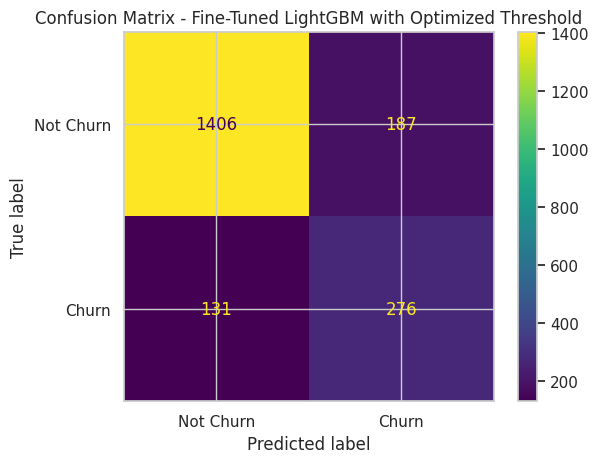

In [ ]:
# 39. Evaluate fine-tuned LightGBM with optimized threshold

# Select the best threshold based on validation F1-score
best_finetuned_threshold = finetuned_threshold_df.iloc[0]["Threshold"]

print("Selected threshold for fine-tuned LightGBM:")
print(best_finetuned_threshold)

# Convert test probabilities into class predictions using the selected threshold
y_pred_lgbm_finetuned_threshold = (
    y_proba_lgbm_finetuned >= best_finetuned_threshold
).astype(int)

# Calculate evaluation metrics
accuracy_lgbm_finetuned_threshold = accuracy_score(
    y_test,
    y_pred_lgbm_finetuned_threshold
)

precision_lgbm_finetuned_threshold = precision_score(
    y_test,
    y_pred_lgbm_finetuned_threshold,
    zero_division=0
)

recall_lgbm_finetuned_threshold = recall_score(
    y_test,
    y_pred_lgbm_finetuned_threshold,
    zero_division=0
)

f1_lgbm_finetuned_threshold = f1_score(
    y_test,
    y_pred_lgbm_finetuned_threshold,
    zero_division=0
)

roc_auc_lgbm_finetuned_threshold = roc_auc_score(
    y_test,
    y_proba_lgbm_finetuned
)

print("Fine-Tuned LightGBM with Optimized Threshold Results")
print(f"Threshold:  {best_finetuned_threshold:.2f}")
print(f"Accuracy:   {accuracy_lgbm_finetuned_threshold:.4f}")
print(f"Precision:  {precision_lgbm_finetuned_threshold:.4f}")
print(f"Recall:     {recall_lgbm_finetuned_threshold:.4f}")
print(f"F1-score:   {f1_lgbm_finetuned_threshold:.4f}")
print(f"ROC-AUC:    {roc_auc_lgbm_finetuned_threshold:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_lgbm_finetuned_threshold,
    zero_division=0
))

# Confusion matrix
cm_lgbm_finetuned_threshold = confusion_matrix(
    y_test,
    y_pred_lgbm_finetuned_threshold
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lgbm_finetuned_threshold,
    display_labels=["Not Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Fine-Tuned LightGBM with Optimized Threshold")
plt.show()

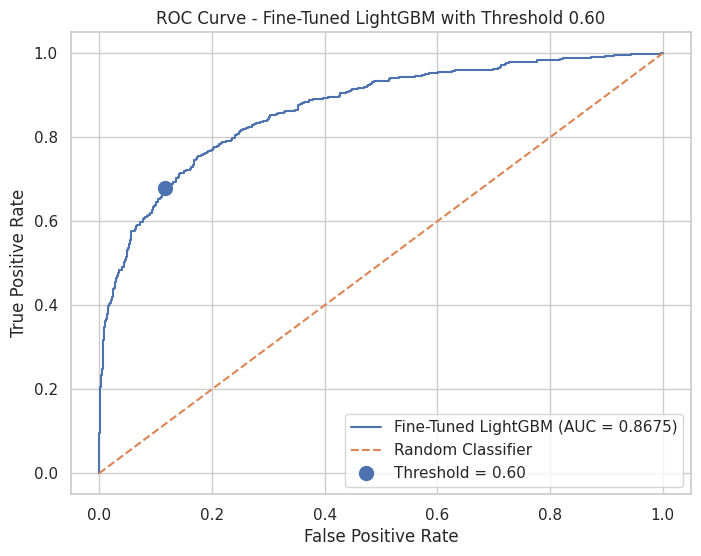

In [ ]:
# ROC Curve with Threshold 0.60 Point

# Get ROC curve values
fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    y_proba_lgbm_finetuned
)

# Extract values from existing confusion matrix
tn, fp, fn, tp = cm_lgbm_finetuned_threshold.ravel()

# Calculate FPR and TPR at selected threshold
fpr_threshold = fp / (fp + tn)
tpr_threshold = tp / (tp + fn)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Fine-Tuned LightGBM (AUC = {roc_auc_lgbm_finetuned_threshold:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.scatter(
    fpr_threshold,
    tpr_threshold,
    s=100,
    label=f"Threshold = {best_finetuned_threshold:.2f}"
)

plt.title("ROC Curve - Fine-Tuned LightGBM with Threshold 0.60")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


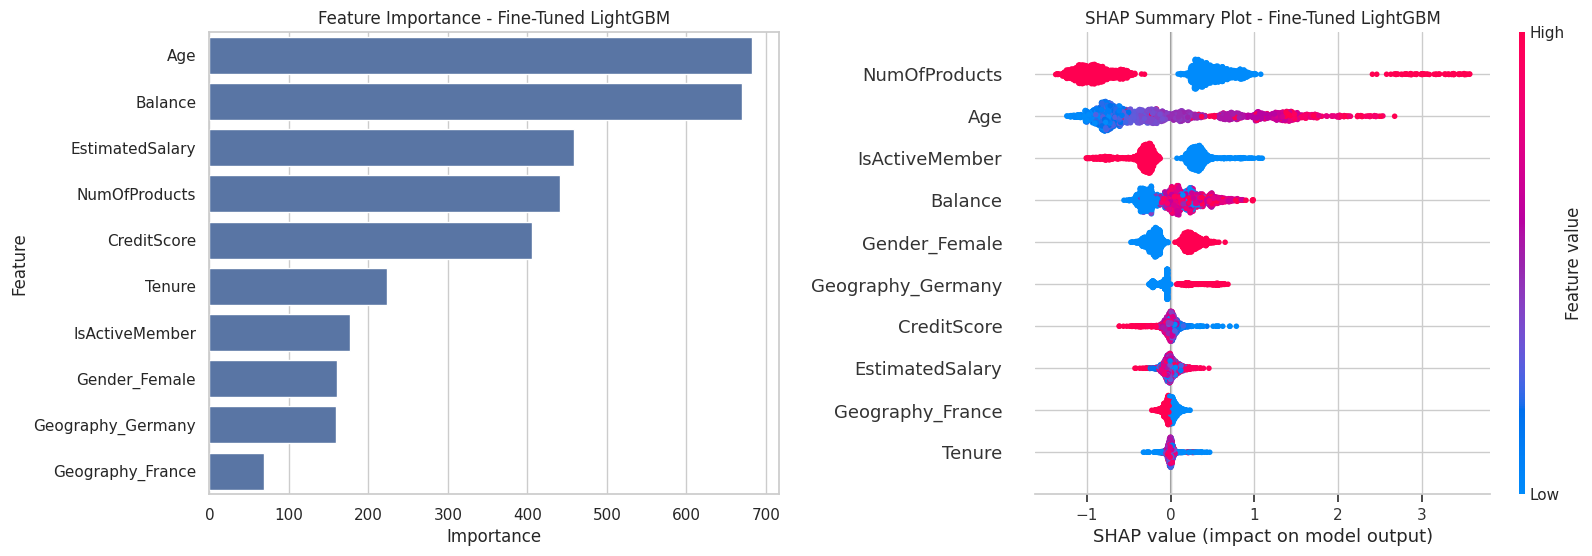

In [ ]:
# Feature Importance + SHAP side by side as two separate plots


# Get feature names after preprocessing
feature_names_ft = numerical_features + list(
    final_preprocessor_ft.named_transformers_["cat"].get_feature_names_out(categorical_features)
)

# Convert transformed test set to DataFrame
X_test_ft_array = (
    X_test_transformed_ft.toarray()
    if hasattr(X_test_transformed_ft, "toarray")
    else X_test_transformed_ft
)

X_test_ft_df = pd.DataFrame(
    X_test_ft_array,
    columns=feature_names_ft
)

# Feature importance dataframe
feature_importance_ft = pd.DataFrame({
    "Feature": feature_names_ft,
    "Importance": final_lgbm_finetuned_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Calculate SHAP values
explainer = shap.TreeExplainer(final_lgbm_finetuned_model)
shap_values = explainer.shap_values(X_test_ft_df)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

# Create two separate plots in the same row
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(18, 6),
    gridspec_kw={"wspace": 0.45}
)

# Plot 1: Feature Importance
sns.barplot(
    data=feature_importance_ft.head(10),
    x="Importance",
    y="Feature",
    ax=axes[0]
)

axes[0].set_title("Feature Importance - Fine-Tuned LightGBM")
axes[0].set_xlabel("Importance")
axes[0].set_ylabel("Feature")

# Plot 2: SHAP Summary Plot
plt.sca(axes[1])

shap.summary_plot(
    shap_values,
    X_test_ft_df,
    max_display=10,
    show=False,
    plot_size=None
)

axes[1].set_title("SHAP Summary Plot - Fine-Tuned LightGBM")

plt.show()

In [ ]:
# 40. Compare final LightGBM models

final_lgbm_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "LightGBM Default",
        "LightGBM Tuned",
        "LightGBM Tuned + Threshold 0.60",
        "Fine-Tuned LightGBM",
        "Fine-Tuned LightGBM + Threshold 0.60"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_lgbm,
        accuracy_lgbm_tuned,
        accuracy_lgbm_tuned_threshold,
        accuracy_lgbm_finetuned,
        accuracy_lgbm_finetuned_threshold
    ],
    "Precision": [
        precision_logistic,
        precision_lgbm,
        precision_lgbm_tuned,
        precision_lgbm_tuned_threshold,
        precision_lgbm_finetuned,
        precision_lgbm_finetuned_threshold
    ],
    "Recall": [
        recall_logistic,
        recall_lgbm,
        recall_lgbm_tuned,
        recall_lgbm_tuned_threshold,
        recall_lgbm_finetuned,
        recall_lgbm_finetuned_threshold
    ],
    "F1-score": [
        f1_logistic,
        f1_lgbm,
        f1_lgbm_tuned,
        f1_lgbm_tuned_threshold,
        f1_lgbm_finetuned,
        f1_lgbm_finetuned_threshold
    ],
    "ROC-AUC": [
        roc_auc_logistic,
        roc_auc_lgbm,
        roc_auc_lgbm_tuned,
        roc_auc_lgbm_tuned_threshold,
        roc_auc_lgbm_finetuned,
        roc_auc_lgbm_finetuned_threshold
    ]
})

final_lgbm_comparison.sort_values(
    by="F1-score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
5,Fine-Tuned LightGBM + Threshold 0.60,0.8410,0.596112,0.678133,0.634483,0.867471
3,LightGBM Tuned + Threshold 0.60,0.8370,0.586724,0.673219,0.627002,0.866955
4,Fine-Tuned LightGBM,0.8010,0.507365,0.761671,0.609037,0.867471
1,LightGBM Default,0.8130,0.530275,0.710074,0.607143,0.857316
2,LightGBM Tuned,0.8000,0.505843,0.744472,0.602386,0.866955
0,Logistic Regression,0.7135,0.387228,0.700246,0.498688,0.777165
